In [103]:
import os

import IPython.display as ipd
import keras
import librosa
import matplotlib.pyplot as plt
import numpy as np
import random
import seaborn as sns
import tensorflow as tf

from keras.models import Sequential
from keras.layers import BatchNormalization, Conv2D, Dense, Dropout, Flatten, MaxPool2D, Reshape

In [ ]:
import os

# 设置 Kaggle API Token 环境变量
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_e760dab1a314bb58b506af8421029c5e'

# 下载并解压数据集
!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
100% 16.0G/16.0G [03:19<00:00, 86.2MB/s]



In [104]:
# Using the standardized 2-second truncated audio files

train_real_directory = "/content/for-2sec/for-2seconds/training/real"
train_fake_directory = "/content/for-2sec/for-2seconds/training/fake"

validation_real_directory = "/content/for-2sec/for-2seconds/validation/real"
validation_fake_directory = "/content/for-2sec/for-2seconds/validation/fake"

test_real_directory = "/content/for-2sec/for-2seconds/testing/real"
test_fake_directory = "/content/for-2sec/for-2seconds/testing/fake"

In [105]:
# Get waveform (.wav) audio files

train_real_audio = [os.path.join(train_real_directory, file) for file in os.listdir(train_real_directory) if file.endswith('.wav')]
train_fake_audio = [os.path.join(train_fake_directory, file) for file in os.listdir(train_fake_directory) if file.endswith('.wav')]

validation_real_audio = [os.path.join(validation_real_directory, file) for file in os.listdir(validation_real_directory) if file.endswith('.wav')]
validation_fake_audio = [os.path.join(validation_fake_directory, file) for file in os.listdir(validation_fake_directory) if file.endswith('.wav')]

test_real_audio = [os.path.join(test_real_directory, file) for file in os.listdir(test_real_directory) if file.endswith('.wav')]
test_fake_audio = [os.path.join(test_fake_directory, file) for file in os.listdir(test_fake_directory) if file.endswith('.wav')]

In [106]:
# Taking a random audio file
random_audio_file = train_real_audio[random.randint(0, 6977)]
ipd.Audio(random_audio_file)

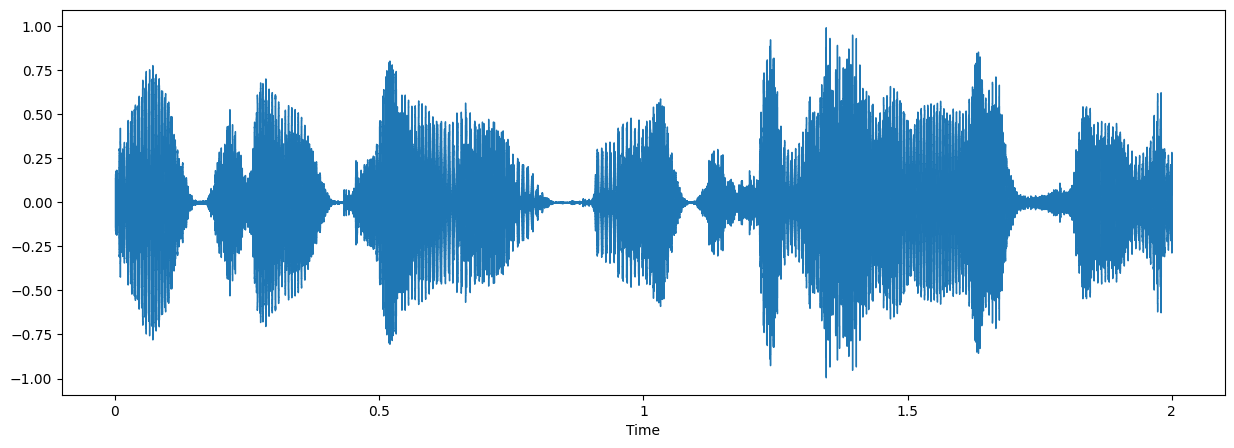

In [107]:
# Visualize waveform of sample audio above
# sr (sample rate) refers to the frequency of "snapshots" of the audio used for digital representation
audio_data, sample_rate = librosa.load(random_audio_file)
plt.figure(figsize=(15, 5))
librosa.display.waveshow(audio_data, sr=sample_rate)

In [122]:
import librosa
import numpy as np

SR = 22050
DURATION = 2.0
N_SAMPLES = int(SR * DURATION)
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048

def create_mel_spectrogram(file_path):
    audio, _ = librosa.load(file_path, sr=SR, duration=DURATION)

    # Pad or truncate to exact length
    audio = librosa.util.fix_length(data=audio, size=N_SAMPLES)

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    # 移除单样本标准化，改为全局标准化
    return mel_db.astype(np.float32)

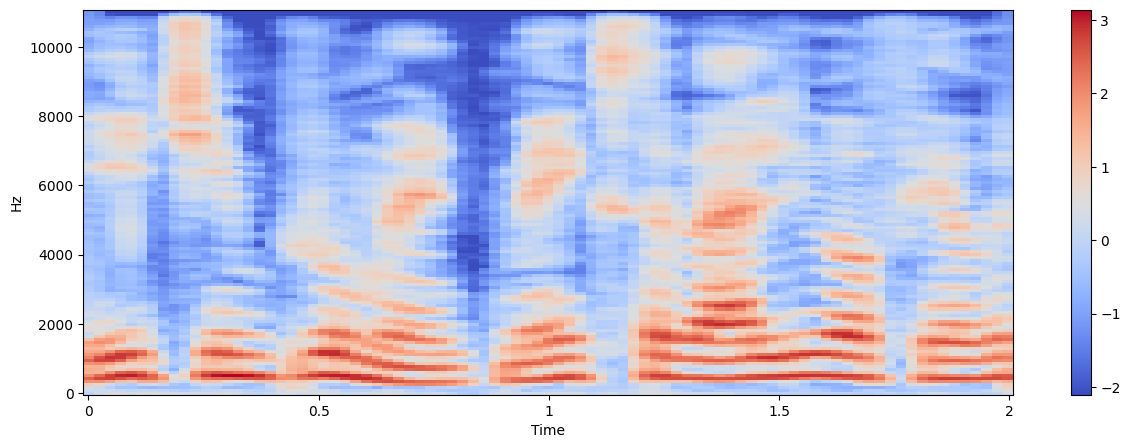

In [109]:
# Spectrogram representation of the sample wave form above
sample_spectrogram = create_mel_spectrogram(random_audio_file)
plt.figure(figsize=(15, 5))
librosa.display.specshow(sample_spectrogram, x_axis='time', y_axis='hz')
plt.colorbar()

In [123]:
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

def build_dataset_arrays(real_audio_files, fake_audio_files, max_workers=4):
    files = real_audio_files + fake_audio_files
    labels = [0] * len(real_audio_files) + [1] * len(fake_audio_files)

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        features = list(tqdm(
            executor.map(create_mel_spectrogram, files),
            total=len(files)
        ))

    features = np.array(features, dtype=np.float32)
    labels = np.array(labels, dtype=np.float32)

    return features, labels

train_features, train_labels = build_dataset_arrays(train_real_audio, train_fake_audio)
validation_features, validation_labels = build_dataset_arrays(validation_real_audio, validation_fake_audio)
test_features, test_labels = build_dataset_arrays(test_real_audio, test_fake_audio)

# 统一全局标准化 (基于训练集)
train_mean = train_features.mean()
train_std = train_features.std()

train_features = (train_features - train_mean) / (train_std + 1e-6)
validation_features = (validation_features - train_mean) / (train_std + 1e-6)
test_features = (test_features - train_mean) / (train_std + 1e-6)

100%|██████████| 1088/1088 [00:19<00:00, 56.90it/s]


In [111]:
print("train features shape: {}".format(train_features.shape))
print("test features shape: {}".format(test_features.shape))

SEED = 42
BATCH_SIZE = 64

def make_tf_dataset(features, labels, training=False):
    features = features[..., np.newaxis]

    ds = tf.data.Dataset.from_tensor_slices((features, labels))

    if training:
        ds = ds.shuffle(4096, seed=SEED)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_tf_dataset(train_features, train_labels, training=True)
val_ds = make_tf_dataset(validation_features, validation_labels)
test_ds = make_tf_dataset(test_features, test_labels)

train features shape: (13956, 128, 87)
test features shape: (1088, 128, 87)


In [124]:
from keras.models import Sequential
from keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPool2D,
    Dropout, Dense, Flatten
)

model = Sequential([
    Input(shape=(128, 87, 1)),

    Conv2D(64, (3, 3), padding="same", activation="relu"),
    Conv2D(64, (3, 3), padding="same", activation="relu"),
    MaxPool2D((2, 2)),
    Dropout(0.2),

    Conv2D(128, (3, 3), padding="same", activation="relu"),
    Conv2D(128, (3, 3), padding="same", activation="relu"),
    MaxPool2D((2, 2)),
    Dropout(0.3),

    Flatten(),

    Dense(256, activation="relu"),
    Dropout(0.4),

    Dense(256, activation="relu"),
    Dropout(0.4),

    Dense(1, activation="sigmoid", dtype="float32")
])

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_37 (Conv2D)              │ (None, 128, 87, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 128, 87, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 64, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 64, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 64, 43, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 32, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86016)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │    22,020,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,345,409 (85.24 MB)

 Trainable params: 22,345,409 (85.24 MB)

 Non-trainable params: 0 (0.00 B)

In [125]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

In [126]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 53s 152ms/step - accuracy: 0.7565 - auc: 0.8499 - loss: 0.5620 - val_accuracy: 0.5000 - val_auc: 0.8334 - val_loss: 0.8897 - learning_rate: 3.0000e-04
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 24s 109ms/step - accuracy: 0.7620 - auc: 0.8321 - loss: 0.5681 - val_accuracy: 0.5000 - val_auc: 0.8245 - val_loss: 0.8935 - learning_rate: 3.0000e-04
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 24s 108ms/step - accuracy: 0.7966 - auc: 0.9138 - loss: 0.4410 - val_accuracy: 0.9671 - val_auc: 0.9937 - val_loss: 0.1307 - learning_rate: 3.0000e-04
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 24s 108ms/step - accuracy: 0.9703 - auc: 0.9929 - loss: 0.1196 - val_accuracy: 0.9618 - val_auc: 0.9967 - val_loss: 0.1104 - learning_rate: 3.0000e-04
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 24s 108ms/step - accuracy: 0.9837 - auc: 0.9974 - loss: 0.0534 - val_accuracy: 0.9908 - val_auc: 0.9981 - val_loss: 0.0396 - learning_rate: 3.0000e-04
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 24s 1

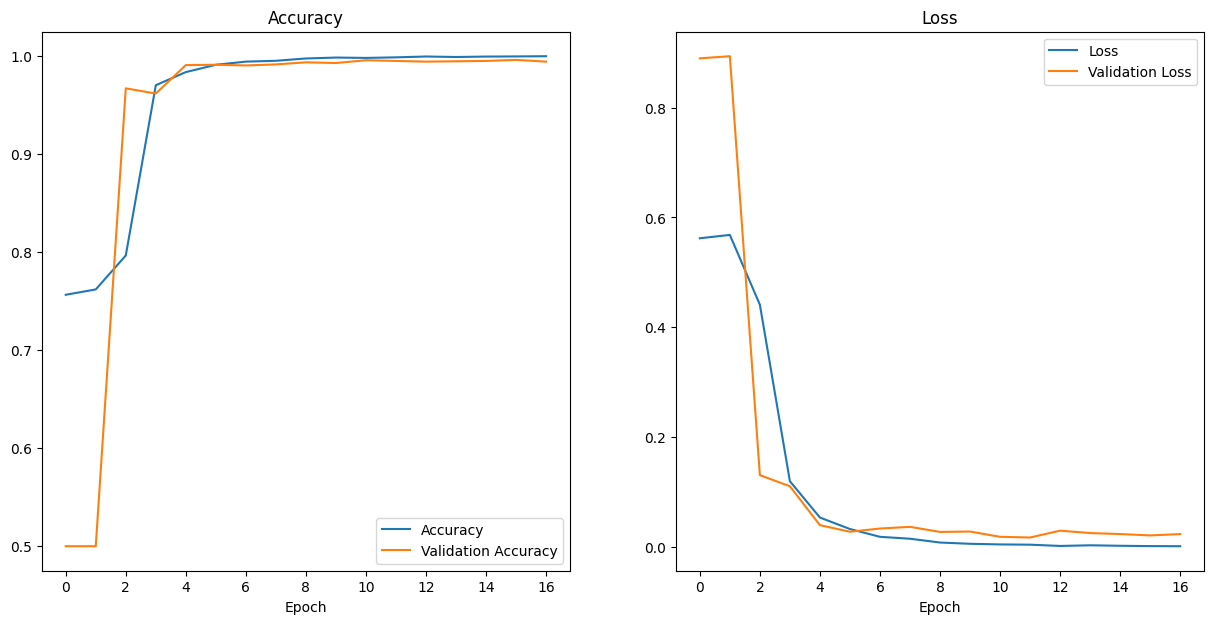

In [127]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

ax1.plot(history.history["accuracy"])
ax1.plot(history.history['val_accuracy'])
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend(["Accuracy","Validation Accuracy"])

ax2.plot(history.history["loss"])
ax2.plot(history.history["val_loss"])
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.legend(["Loss","Validation Loss"])

plt.show()

In [128]:
# Test Data Results

test_loss, test_acc, test_auc = model.evaluate(test_ds)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)
print("Test AUC:", test_auc)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5000 - auc: 0.5294 - loss: 4.4862
Test loss: 4.486186981201172
Test accuracy: 0.5
Test AUC: 0.529411792755127


In [129]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve

val_probs = model.predict(val_ds).ravel()
test_probs = model.predict(test_ds).ravel()

fpr, tpr, thresholds = roc_curve(validation_labels, val_probs)
best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)

test_preds = (test_probs >= best_threshold).astype(int)

print("Test accuracy with best threshold:", accuracy_score(test_labels, test_preds))
print(classification_report(test_labels, test_preds, target_names=["real", "fake"]))
print(confusion_matrix(test_labels, test_preds))


45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Best threshold: 0.5911976
Test accuracy with best threshold: 0.5
              precision    recall  f1-score   support

        real       0.50      1.00      0.67       544
        fake       0.00      0.00      0.00       544

    accuracy                           0.50      1088
   macro avg       0.25      0.50      0.33      1088
weighted avg       0.25      0.50      0.33      1088

[[544   0]
 [544   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## PyTorch + Optuna Pipeline

In [138]:
!pip install optuna
import os
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import optuna
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tqdm import tqdm

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Jika menggunakan multi-GPU

    # Memastikan algoritma konvolusi di cuDNN bersifat deterministik
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Global seed set to: {seed}")

set_seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.8 MB/s eta 0:00:00
Global seed set to: 42


In [139]:
# ==========================================
# 1. FUNGSI INPUT DATA
# ==========================================
def get_scenefake_data(root_dir):
    data = []
    splits = {'train': 'training', 'dev': 'validation', 'eval': 'testing'}

    for folder_name, split_label in splits.items():
        folder_path = os.path.join(root_dir, folder_name)
        if not os.path.exists(folder_path):
            continue

        for label in ['real', 'fake']:
            label_path = os.path.join(folder_path, label)
            if os.path.exists(label_path):
                for file in os.listdir(label_path):
                    if file.endswith(('.wav', '.mp3', '.flac')):
                        data.append({
                            'file_path': os.path.join(label_path, file),
                            'label': label,
                            'split': split_label,
                            'source': 'SceneFake'
                        })
    return pd.DataFrame(data)

def get_fake_or_real_data(root_dir):
    data = []
    # Sesuai: for-2sec -> for-2seconds -> [training, testing, validation]
    base_path = os.path.join(root_dir, 'for-2sec', 'for-2seconds')

    splits = ['training', 'validation', 'testing']

    for split in splits:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            continue

        for label in ['real', 'fake']:
            label_path = os.path.join(split_path, label)
            if os.path.exists(label_path):
                for file in os.listdir(label_path):
                    if file.endswith(('.wav', '.mp3', '.flac')):
                        data.append({
                            'file_path': os.path.join(label_path, file),
                            'label': label,
                            'split': split,
                            'source': 'FakeOrReal'
                        })
    return pd.DataFrame(data)

In [140]:
# ==========================================
# 2. DATASET & PRE-PROCESSING (LOG-MEL SPECTROGRAM)
# ==========================================
class AudioDeepfakeDataset(Dataset):
    def __init__(self, dataframe, sample_rate=16000, n_mels=128, max_len=130):
        self.data = dataframe
        self.sample_rate = sample_rate
        self.max_len = max_len

        self.mel_spectrogram = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate, n_fft=1024, hop_length=512, n_mels=n_mels
        )
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        file_path = self.data.iloc[idx]['file_path']
        label_str = self.data.iloc[idx]['label']
        label = 1 if label_str == 'fake' else 0

        try:
            waveform, sr = torchaudio.load(file_path)

            # Resample jika diperlukan
            if sr != self.sample_rate:
                resampler = torchaudio.transforms.Resample(sr, self.sample_rate)
                waveform = resampler(waveform)

            # Konversi stereo ke mono
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)

            # Ekstraksi Log-Mel Spectrogram
            mel_spec = self.mel_spectrogram(waveform)
            log_mel_spec = self.amplitude_to_db(mel_spec)

            # Padding/Truncating ke max_len
            if log_mel_spec.shape[2] > self.max_len:
                log_mel_spec = log_mel_spec[:, :, :self.max_len]
            else:
                padding = self.max_len - log_mel_spec.shape[2]
                log_mel_spec = torch.nn.functional.pad(log_mel_spec, (0, padding))

        except Exception as e:
            # Fallback tensor jika file korup
            log_mel_spec = torch.zeros((1, 128, self.max_len))

        return log_mel_spec, torch.tensor(label, dtype=torch.float32)

class MelSpectrogramProcessor:
    def __init__(self, sample_rate=16000, n_mels=128, n_fft=1024, hop_length=512, target_length=256):
        self.sample_rate = sample_rate
        self.n_mels = n_mels
        self.target_length = target_length
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length
        )
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB()

    def load_and_preprocess_audio(self, file_path):
        try:
            waveform, sr = torchaudio.load(file_path)
            if waveform.shape[0] > 1:
                waveform = waveform.mean(dim=0, keepdim=True)
            if sr != self.sample_rate:
                resampler = torchaudio.transforms.Resample(sr, self.sample_rate)
                waveform = resampler(waveform)

            mel_spec_db = self.amplitude_to_db(self.mel_transform(waveform))

            if mel_spec_db.shape[2] > self.target_length:
                mel_spec_db = mel_spec_db[:, :, :self.target_length]
            else:
                pad_amount = self.target_length - mel_spec_db.shape[2]
                mel_spec_db = F.pad(mel_spec_db, (0, pad_amount))

            mel_spec_db = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-8)
            return mel_spec_db.squeeze(0)
        except Exception as e:
            print(f"Gagal memproses {file_path}: {e}")
            return None

In [141]:
# ==========================================
# 3. ARSITEKTUR HYBRID MODEL + DUAL ATTENTION
# ==========================================
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1 = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv1(x)
        return self.sigmoid(x)

class HybridAST(nn.Module):
    def __init__(self, n_mels=128, num_heads=4, hidden_dim=256, num_layers=2):
        super(HybridAST, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.ca = ChannelAttention(32)
        self.sa = SpatialAttention()

        self.feature_dim = 32 * (n_mels // 2)
        self.linear_proj = nn.Linear(self.feature_dim, hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv(x)
        x = x * self.ca(x)
        x = x * self.sa(x)

        B, C, H, W = x.shape
        x = x.permute(0, 3, 1, 2).contiguous()
        x = x.view(B, W, C * H)

        x = self.linear_proj(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        out = self.classifier(x)
        return out.squeeze(1)

In [142]:
# ==========================================
# 4. TRAINING & EVALUATION & OPTIMIZATION
# ==========================================
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, device, epochs=5):
    best_val_auc = 0.0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for inputs, labels in train_pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            train_pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        model.eval()
        all_labels = []
        all_preds = []
        all_probs = []

        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
        with torch.no_grad():
            for inputs, labels in val_pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                probs = model(inputs)
                preds = (probs > 0.5).float()

                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        acc = accuracy_score(all_labels, all_preds)
        prec = precision_score(all_labels, all_preds, zero_division=0)
        rec = recall_score(all_labels, all_preds, zero_division=0)
        f1 = f1_score(all_labels, all_preds, zero_division=0)

        try:
            auc = roc_auc_score(all_labels, all_probs)
        except ValueError:
            auc = 0.0

        print(f"\n=> Loss: {total_loss/len(train_loader):.4f} | Val Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}\n")

        if auc > best_val_auc:
            best_val_auc = auc

    return best_val_auc

def objective(trial, df_train, df_val, device):
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    num_heads = trial.suggest_categorical("num_heads", [2, 4, 8])
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256])

    train_dataset = AudioDeepfakeDataset(df_train)
    val_dataset = AudioDeepfakeDataset(df_val)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    model = HybridAST(num_heads=num_heads, hidden_dim=hidden_dim).to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Latih 3 epoch untuk mencari parameter
    val_auc = train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, device, epochs=3)

    return val_auc

In [146]:
# Download missing SceneFake dataset
import os

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_e760dab1a314bb58b506af8421029c5e' # Menggunakan token Anda yang sebelumnya

!kaggle datasets download -d mohammedabdeldayem/scenefake --unzip -p /content/scenefake

print("SceneFake dataset berhasil diunduh ke /content/scenefake")

Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/scenefake
License(s): CC-BY-NC-SA-4.0
100% 5.37G/5.37G [01:40<00:00, 57.3MB/s]

SceneFake dataset berhasil diunduh ke /content/scenefake


In [147]:
# ==========================================
# 5. BLOK EKSEKUSI UTAMA (COLAB PATHS)
# ==========================================
if __name__ == "__main__":
    # Path dataset disesuaikan untuk environment Colab
    PATH_SCENEFAKE = '/content/scenefake' # Jika tidak ada, fungsi akan skip dengan sendirinya
    PATH_FOR = '/content'                 # Data sudah diekstrak di /content/for-2sec/for-2seconds

    print("\n--- Memuat Dataset ---")
    df_scene = get_scenefake_data(PATH_SCENEFAKE)
    df_for = get_fake_or_real_data(PATH_FOR)

    df_all = pd.concat([df_scene, df_for], ignore_index=True)

    if len(df_all) == 0:
        print("ERROR: Tidak ada data yang dimuat. Periksa kembali PATH dataset Anda.")
    else:
        # 2. Split Awal berdasarkan kolom 'split'
        df_train = df_all[df_all['split'] == 'training'].reset_index(drop=True)
        df_val = df_all[df_all['split'] == 'validation'].reset_index(drop=True)

        print(f"Data Sebelum Oversampling -> Train: {len(df_train)}, Val: {len(df_val)}")

        # 3. PROSES OVERSAMPLING (Menyeimbangkan Kelas Real & Fake)
        if not df_train.empty:
            max_train = df_train['label'].value_counts().max()
            df_train = pd.concat([
                df_train[df_train['label'] == 'real'].sample(n=max_train, replace=True, random_state=42),
                df_train[df_train['label'] == 'fake'].sample(n=max_train, replace=True, random_state=42)
            ]).sample(frac=1, random_state=42).reset_index(drop=True)

        if not df_val.empty:
            max_val = df_val['label'].value_counts().max()
            df_val = pd.concat([
                df_val[df_val['label'] == 'real'].sample(n=max_val, replace=True, random_state=42),
                df_val[df_val['label'] == 'fake'].sample(n=max_val, replace=True, random_state=42)
            ]).sample(frac=1, random_state=42).reset_index(drop=True)

        print(f"Data SESUDAH Oversampling -> Train: {len(df_train)}, Val: {len(df_val)}")
        print(f"Distribusi Label Train:\n{df_train['label'].value_counts()}")

        # 4. Inisialisasi Perangkat
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"\nMenggunakan perangkat: {device}\n")

        # 5. Mulai Optuna
        print("--- Memulai Bayesian Optimization ---")
        study = optuna.create_study(direction="maximize")

        # Menggunakan 2 trial untuk tes awal (bisa diubah)
        study.optimize(lambda trial: objective(trial, df_train, df_val, device), n_trials=2)

        print("\n=== HASIL BAYESIAN OPTIMIZATION ===")
        print("Nilai AUC terbaik: ", study.best_value)
        print("Hyperparameter terbaik: ", study.best_params)


--- Memuat Dataset ---
Data Sebelum Oversampling -> Train: 27141, Val: 15669


[I 2026-04-28 16:09:07,175] A new study created in memory with name: no-name-54951397-8a24-4229-9b00-47a9e9296f64


Data SESUDAH Oversampling -> Train: 35276, Val: 23416
Distribusi Label Train:
label
fake    17638
real    17638
Name: count, dtype: int64

Menggunakan perangkat: cuda

--- Memulai Bayesian Optimization ---


Epoch 1/3 [Val]: 100%|██████████| 732/732 [03:31<00:00,  3.46it/s]



=> Loss: 0.1773 | Val Acc: 0.8806 | Prec: 0.8383 | Rec: 0.9429 | F1: 0.8876 | AUC: 0.9441



...


=> Loss: 0.1539 | Val Acc: 0.8458 | Prec: 0.7785 | Rec: 0.9668 | F1: 0.8625 | AUC: 0.9281



Epoch 2/3 [Val]: 100%|██████████| 732/732 [03:25<00:00,  3.57it/s]



=> Loss: 0.0357 | Val Acc: 0.8702 | Prec: 0.7987 | Rec: 0.9898 | F1: 0.8841 | AUC: 0.9425



Epoch 3/3 [Val]: 100%|██████████| 732/732 [03:20<00:00,  3.65it/s]
[I 2026-04-28 16:57:41,143] Trial 1 finished with value: 0.9425092625134391 and parameters: {'lr': 0.0001565720013349646, 'num_heads': 2, 'hidden_dim': 256}. Best is trial 0 with value: 0.9463061066056877.



=> Loss: 0.0196 | Val Acc: 0.8849 | Prec: 0.8133 | Rec: 0.9992 | F1: 0.8967 | AUC: 0.9278


=== HASIL BAYESIAN OPTIMIZATION ===
Nilai AUC terbaik:  0.9463061066056877
Hyperparameter terbaik:  {'lr': 0.00021915889108484302, 'num_heads': 4, 'hidden_dim': 128}


Melatih Model Final dengan: {'lr': 0.00021915889108484302, 'num_heads': 4, 'hidden_dim': 128}

--- Memulai Training Final ---


Epoch 1: 100%|██████████| 1103/1103 [04:30<00:00,  4.08it/s]


Val Acc: 0.8685 | Val AUC: 0.9340


Epoch 2: 100%|██████████| 1103/1103 [04:34<00:00,  4.02it/s]


Val Acc: 0.8891 | Val AUC: 0.9704


...

Val Acc: 0.8956 | Val AUC: 0.9632


Epoch 9: 100%|██████████| 1103/1103 [04:29<00:00,  4.09it/s]


Val Acc: 0.8918 | Val AUC: 0.9576


Epoch 10: 100%|██████████| 1103/1103 [04:29<00:00,  4.09it/s]


Val Acc: 0.8926 | Val AUC: 0.9296


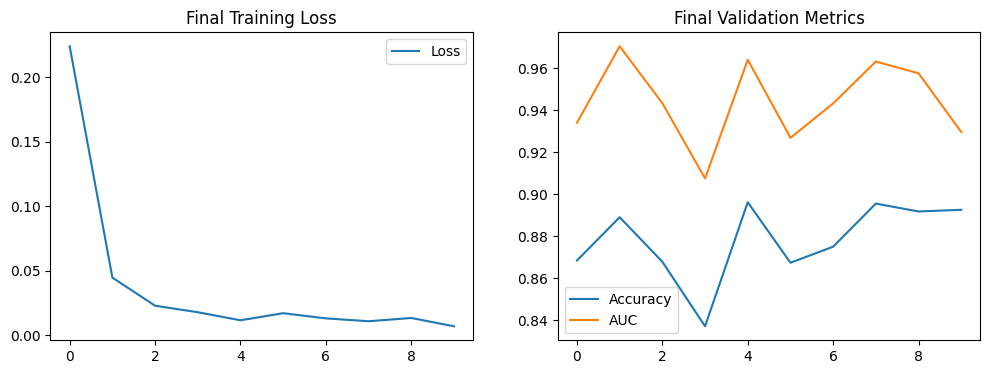


Model final telah disimpan sebagai 'HybridAST_Deepfake_Detector.pth'


In [148]:
# ==========================================
# 6. TRAINING FINAL & VISUALISASI PERFORMA
# ==========================================
import matplotlib.pyplot as plt

# 1. Ambil parameter terbaik dari hasil Optuna Anda
best_params = study.best_params
print(f"Melatih Model Final dengan: {best_params}")

# 2. Siapkan DataLoader Final (Sertakan folder Testing)
train_dataset = AudioDeepfakeDataset(df_train)
val_dataset = AudioDeepfakeDataset(df_val)
test_dataset = AudioDeepfakeDataset(df_all[df_all['split'] == 'testing'].reset_index(drop=True))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 3. Inisialisasi Model dengan Parameter Terbaik
final_model = HybridAST(
    num_heads=best_params['num_heads'],
    hidden_dim=best_params['hidden_dim']
).to(device)

optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params['lr'])
criterion = nn.BCELoss()

# 4. Loop Training Final (Misal: 10 Epoch untuk mematangkan)
history = {'loss': [], 'acc': [], 'auc': []}
epochs_final = 10

print("\n--- Memulai Training Final ---")
for epoch in range(epochs_final):
    final_model.train()
    epoch_loss = 0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Evaluasi singkat per epoch
    final_model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = final_model(inputs.to(device))
            all_probs.extend(outputs.cpu().numpy())
            all_labels.extend(labels.numpy())

    current_auc = roc_auc_score(all_labels, all_probs)
    current_acc = accuracy_score(all_labels, [1 if p > 0.5 else 0 for p in all_probs])

    history['loss'].append(epoch_loss/len(train_loader))
    history['acc'].append(current_acc)
    history['auc'].append(current_auc)
    print(f"Val Acc: {current_acc:.4f} | Val AUC: {current_auc:.4f}")

# 5. VISUALISASI HASIL
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Loss')
plt.title('Final Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['acc'], label='Accuracy')
plt.plot(history['auc'], label='AUC')
plt.title('Final Validation Metrics')
plt.legend()
plt.show()

# 6. SIMPAN MODEL
torch.save(final_model.state_dict(), "HybridAST_Deepfake_Detector.pth")
print("\nModel final telah disimpan sebagai 'HybridAST_Deepfake_Detector.pth'")

--- Mengevaluasi Model pada Data Testing ---


Testing: 100%|██████████| 1058/1058 [06:59<00:00,  2.52it/s]



HASIL EVALUASI KOMPREHENSIF
              precision    recall  f1-score   support

        Real     0.8790    0.6960    0.7769      6878
        Fake     0.9263    0.9756    0.9503     26956

    accuracy                         0.9187     33834
   macro avg     0.9027    0.8358    0.8636     33834
weighted avg     0.9167    0.9187    0.9151     33834

ROC-AUC SCORE: 0.9110


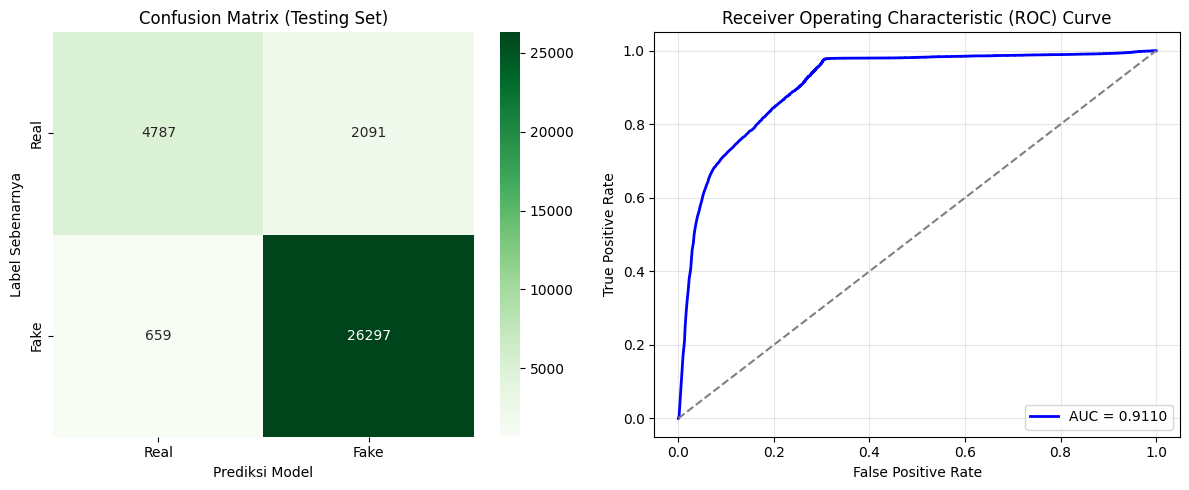

In [149]:
# ==========================================
# 7. EVALUASI TEST SET
# ==========================================
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

def display_final_metrics(model, test_loader, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    print("--- Mengevaluasi Model pada Data Testing ---")
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Testing"):
            inputs = inputs.to(device)
            outputs = model(inputs)

            # Ambil probabilitas mentah dan hasil prediksi (threshold 0.5)
            probs = outputs.cpu().numpy()
            preds = (outputs > 0.5).float().cpu().numpy()

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    # 1. Classification Report (Metrik Utama)
    print("\n" + "="*30)
    print("HASIL EVALUASI KOMPREHENSIF")
    print("="*30)
    print(classification_report(all_labels, all_preds, target_names=['Real', 'Fake'], digits=4))

    # 2. Perhitungan ROC-AUC Final
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    final_roc_auc = auc(fpr, tpr)
    print(f"ROC-AUC SCORE: {final_roc_auc:.4f}")

    # 3. Visualisasi Confusion Matrix
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.title('Confusion Matrix (Testing Set)')
    plt.xlabel('Prediksi Model')
    plt.ylabel('Label Sebenarnya')

    # 4. Visualisasi Kurva ROC
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {final_roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Eksekusi fungsi evaluasi
display_final_metrics(final_model, test_loader, device)